## Connect MySQL and Python 

In [1]:
from sqlalchemy import create_engine

# MySQL Connection
username = "root"
password = "root"
host = "localhost"
port = 3306
database = "churn_prediction"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

print("Database Connected Successfully!")

Database Connected Successfully!


#### Import Essential libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

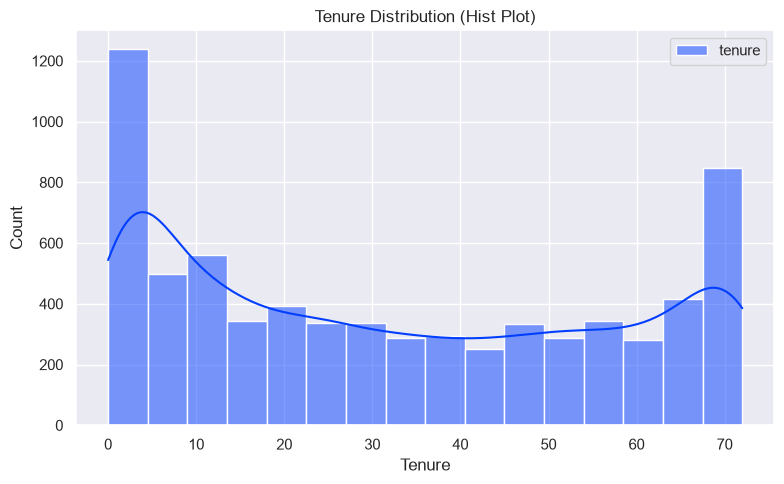

In [23]:
q1 = """
    SELECT
        tenure
    FROM billing
"""

df1=pd.read_sql(q1, engine)

sns.set_theme(style='whitegrid')
sns.set_palette('bright')
sns.set_style("darkgrid")
plt.figure(figsize=(8, 5))
sns.histplot(df1, kde=True)
plt.title('Tenure Distribution (Hist Plot)')
plt.xlabel('Tenure')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('tenure_distribution.png')
plt.show()

## Insight
###### Distribution bimodal hai (U-shape) — sabse zyada customers 0-2 months tenure pe hain (~1200+), aur dusra bada cluster 65-72 months (~850) pe hai
###### Beech ke tenure range (20-50 months) me comparatively kam customers hain
###### Matlab: jo customer shuru ke kuch mahine paar kar leta hai, wo generally lambe time tak retain hota hai — "early churn window" sabse critical phase hai
###### Feature engineering ke liye tenure ko raw continuous rakhne ke bajaye bins (0-6, 6-24, 24-48, 48+) me convert karna better rahega, kyunki relationship linear nahi hai

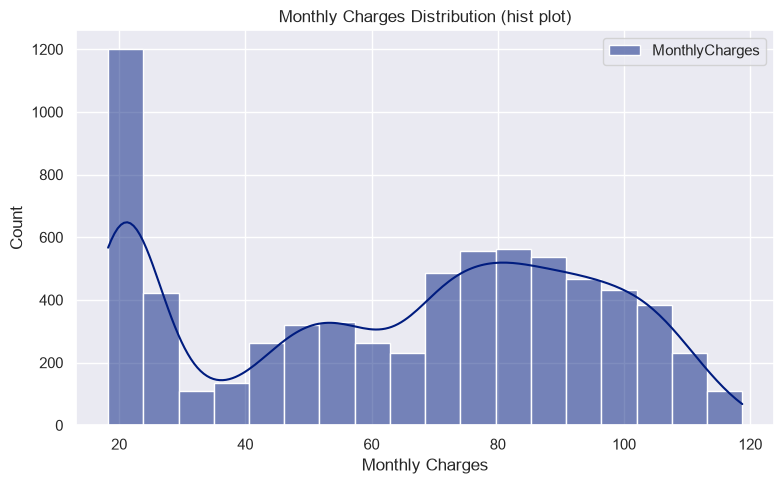

In [22]:
q2="""
    SELECT
        MonthlyCharges
    FROM billing
"""

df2=pd.read_sql(q2, engine)

plt.figure(figsize=(8, 5))

sns.set_theme(style='whitegrid')
sns.set_style('darkgrid')
sns.set_palette('dark')

sns.histplot(df2, kde=True)
plt.title('Monthly Charges Distribution (hist plot)')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('Monthly_Charges_distribution.png')
plt.show()

## Insight
###### Distribution bimodal hai — ek spike ~$20 pe (basic/no-frills single-service plans) aur ek broad peak $70-100 range me (bundled/premium plans)
###### Ye do alag customer segments suggest karta hai: low-cost minimal users vs high-value bundled users
###### High MonthlyCharges wala segment fiber optic/premium services se overlap karta hai — churn ke against isko cross-check karna zaroori hai, kyunki fiber optic customers me churn zyada dekha gaya hai

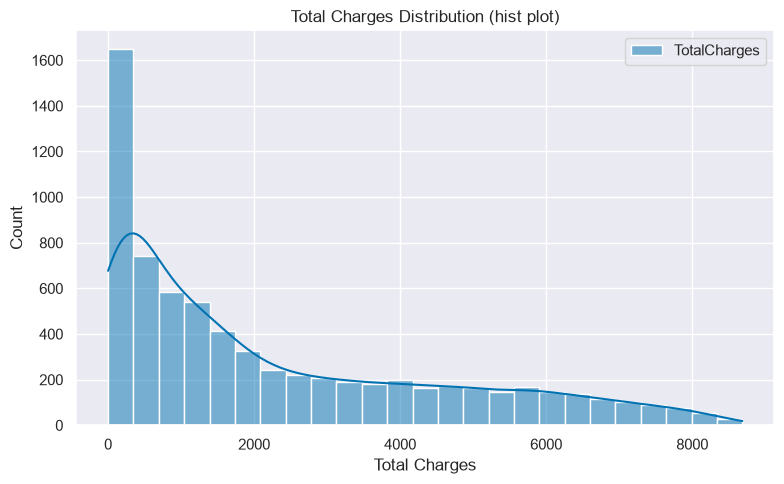

In [21]:
q3="""
    SELECT
        TotalCharges
    FROM billing
"""

df3=pd.read_sql(q3, engine)

plt.figure(figsize=(8, 5))

sns.set_theme(style='darkgrid')
sns.set_style('darkgrid')
sns.set_palette('colorblind')

sns.histplot(df3, kde=True)
plt.title('Total Charges Distribution (hist plot)')
plt.xlabel('Total Charges')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('Total_Charges_Distribution.png')
plt.show()

## Insight
###### Distribution heavily right-skewed hai — zyadatar customers ka TotalCharges 0-1000 range me hai, tail lambi 8000+ tak jaati hai
###### Ye expected hai kyunki TotalCharges ≈ tenure × MonthlyCharges, aur naye customers (kam tenure) dataset me zyada hain
###### Linear/logistic regression jaise models use karne se pehle log-transform consider karo, skewness ka effect kam karne ke liye

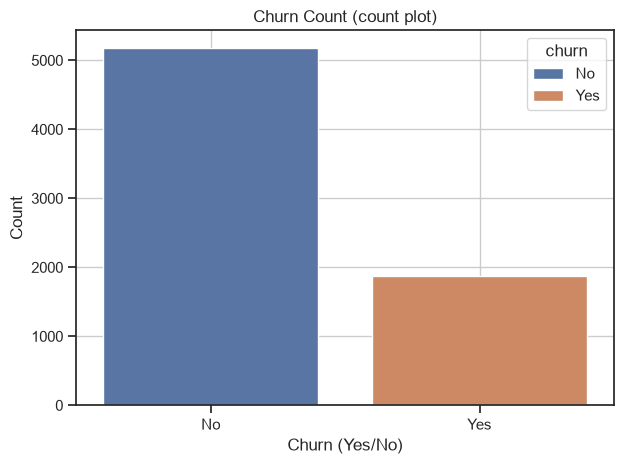

In [20]:
q4="""
    SELECT
        churn
    FROM billing
"""
sns.set_theme(style='whitegrid')
sns.set_style('ticks')

df4=pd.read_sql(q4, engine)

sns.countplot(data=df4, x="churn", hue='churn', legend=True)
plt.grid(True)
plt.title('Churn Count (count plot)')
plt.xlabel('Churn (Yes/No)')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('Churn_Count.png')
plt.show()

## Insight
###### ~73% customers retained (No churn ~5174) aur ~27% churned (Yes ~1869) — clear class imbalance hai
###### Train-test split karte waqt stratify=y zaroor use karna, warna class ratio maintain nahi hoga
###### Accuracy metric is imbalance ki wajah se misleading hogi — Precision, Recall, F1-score aur ROC-AUC pe focus karo model evaluate karte waqt

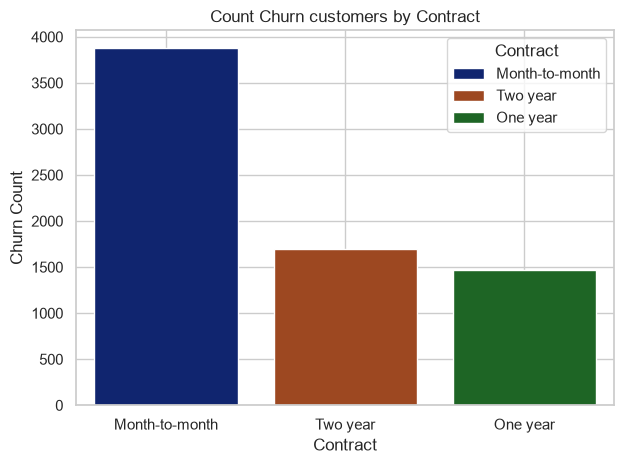

In [19]:
q5="""
    SELECT
        Contract,
        COUNT(churn) AS total_churn
    FROM billing
    GROUP BY Contract
    ORDER BY total_churn DESC
"""

df5=pd.read_sql(q5, engine)

sns.set_theme(style='whitegrid')
sns.set_style('whitegrid')
sns.set_palette('dark')

sns.barplot(x='Contract', y='total_churn', data=df5, hue='Contract', legend=True)
plt.grid(True)
plt.title('Count Churn customers by Contract')
plt.xlabel('Contract')
plt.ylabel('Churn Count')

plt.tight_layout()
plt.savefig('count_churn_customers_by_contract.png')
plt.show()

## Insight
###### Month-to-month contract customers me churn count sabse zyada hai (~3875), One year (~1450) aur Two year (~1685) me kaafi kam
###### Ye raw COUNT hai, RATE nahi — month-to-month base me customers bhi zyada hain, isliye fair comparison ke liye churn RATE heatmap (Contract × InternetService) saath me dekhna zaroori hai
###### Overall trend clear hai: jitna lamba contract commitment, utna kam churn — contract type strongest retention driver lag raha hai

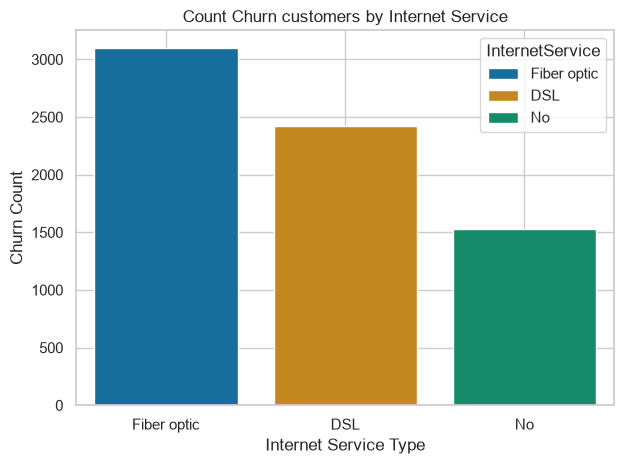

In [18]:
q6="""
    SELECT
        s.InternetService,
        COUNT(b.churn) AS total_churn
    FROM services s
    JOIN customers c
    ON s.customerID=c.customerID
    JOIN billing b
    ON c.customerID=b.customerID
    GROUP BY s.InternetService
    ORDER BY total_churn DESC
"""

df6=pd.read_sql(q6, engine)

sns.set_theme(style='whitegrid')
sns.set_style('whitegrid')
sns.set_palette('colorblind')

sns.barplot(x='InternetService', y='total_churn', data=df6, hue='InternetService', legend=True)
plt.grid(True)
plt.title('Count Churn customers by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Count')

plt.tight_layout()
plt.savefig('count_churn_customers_by_internet_service.png')
plt.show()

## Insight
###### Fiber optic customers me churn count sabse zyada hai (~3096), phir DSL (~2421), phir No internet service (~1526)
###### Fiber optic ek premium/faster service hone ke bawajood highest churn dikha raha hai — ye pricing issue ya service quality issue ka signal ho sakta hai, feature limitation nahi
###### Ye bhi raw count hai — rate perspective se dekhne ke liye Contract × InternetService churn rate heatmap zyada meaningful hai

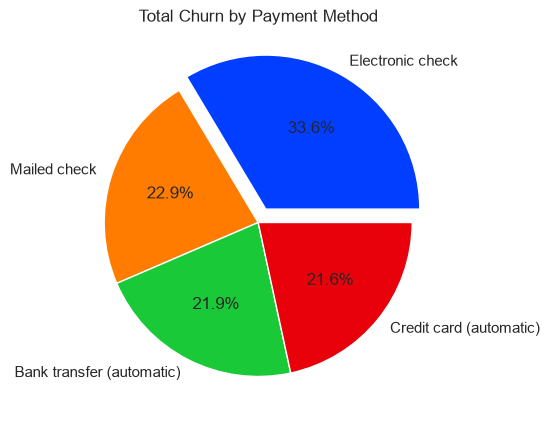

In [17]:
q7="""
    SELECT
        PaymentMethod,
        COUNT(churn) AS total_churn
    FROM billing
    GROUP BY PaymentMethod
    ORDER BY total_churn DESC
"""

df7=pd.read_sql(q7, engine)

sns.set_theme(style='whitegrid')
sns.set_style('whitegrid')
sns.set_palette('bright')

plt.figure(figsize=(5, 5))

plt.pie(x='total_churn', labels='PaymentMethod', autopct='%1.1f%%', data=df7, explode=(0.1, 0, 0, 0))
plt.title('Total Churn by Payment Method')
plt.savefig('total_churn_by_payment_method.png')

plt.show()

## Insight
###### Electronic check se sabse zyada churn hua hai (33.6%), phir Mailed check (22.9%), Bank transfer (21.9%), aur Credit card (21.6%)
###### Auto-pay methods (Bank transfer, Credit card) me manual payment methods (Electronic/Mailed check) ke comparison me kam churn dikh raha hai
###### Manual payment disengagement/friction ka proxy ho sakta hai — customers ko auto-pay pe switch karne ke liye incentivize karna ek possible retention strategy ho sakti hai

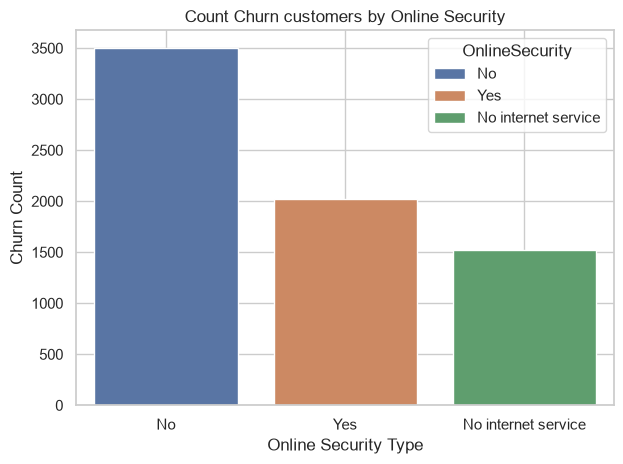

In [16]:
q8="""
    SELECT
        s.OnlineSecurity,
        COUNT(b.churn) AS total_churn
    FROM services s
    JOIN customers c
    ON s.customerID=c.customerID
    JOIN billing b
    ON c.customerID=b.customerID
    GROUP BY s.OnlineSecurity
    ORDER BY total_churn DESC
"""

df8=pd.read_sql(q8, engine)

sns.set_theme(style='whitegrid')
sns.set_style('whitegrid')
sns.set_palette('deep')

sns.barplot(x='OnlineSecurity', y='total_churn', data=df8, hue='OnlineSecurity', legend=True)
plt.grid(True)
plt.title('Count Churn customers by Online Security')
plt.xlabel('Online Security Type')
plt.ylabel('Churn Count')

plt.tight_layout()
plt.savefig('churn_count_customers_by_online_security.png')
plt.show()

## Insight
###### OnlineSecurity na lene wale customers me churn count sabse zyada hai (~3498), 'Yes' wale me ~2015, aur 'No internet service' wale me ~1526
###### Pattern clear hai: jo customers protective/value-added addons nahi lete, unme churn zyada hai — addon adoption retention ke saath positively correlated lag raha hai
###### Isse upsell opportunity milti hai — OnlineSecurity jaise addons ko bundle/promote karna churn kam karne me help kar sakta hai

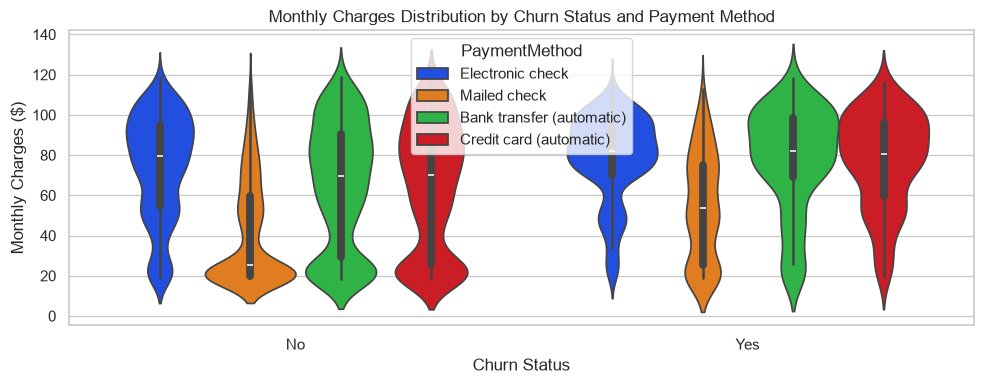

In [15]:
q9="""
    SELECT
        *
    FROM billing
"""

df9=pd.read_sql(q9, engine)

sns.set_theme(style='whitegrid')
sns.set_palette('bright')

plt.figure(figsize=(10, 4))
sns.violinplot(data=df9, y='MonthlyCharges', x='Churn', hue='PaymentMethod')
plt.title('Monthly Charges Distribution by Churn Status and Payment Method')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('Monthly_charges_distribution_by_Churn_and_payment_method.png')
plt.show()

## Insight
###### Payment method ke hisaab se MonthlyCharges alag-alag hai — Electronic check, Bank transfer aur Credit card (dono automatic) wale customers ka median monthly charge, Mailed check wale customers se zyada hai
###### Churned (Yes) aur non-churned (No) customers ki distributions har payment method ke andar kaafi overlap karti hain
###### Iska matlab: akela payment method churn ko strongly differentiate nahi karta — ye ek contributing factor hai, standalone predictor nahi; Contract aur InternetService jaise features ke saath combine karke dekhna zyada useful hoga

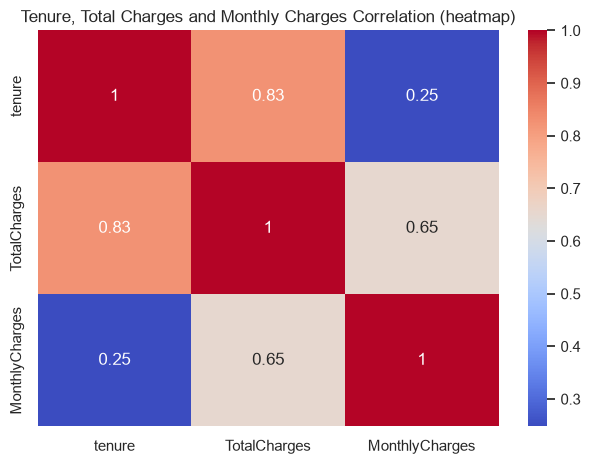

In [14]:
q10="""
    SELECT
        tenure,
        TotalCharges,
        MonthlyCharges
    FROM billing
"""

df10=pd.read_sql(q10, engine)

heatmap_data=df10.corr()

sns.heatmap(heatmap_data, annot=True, cmap="coolwarm")
plt.title('Tenure, Total Charges and Monthly Charges Correlation (heatmap)')

plt.tight_layout()
plt.savefig('Tenure, Total and Monthly_Charges Correlation.png')
plt.show()

## Insight
###### tenure aur TotalCharges ka correlation bahut high hai (0.83) — dono ek jaisi information capture kar rahe hain
###### TotalCharges aur MonthlyCharges ka correlation moderate hai (0.65), jabki tenure aur MonthlyCharges ka correlation weak hai (0.25) — ye do independent signals hain
###### Modeling ke liye multicollinearity avoid karne hetu TotalCharges ko drop karna consider karo (ya sirf tenure + MonthlyCharges use karo), kyunki TotalCharges largely tenure se hi derive hoti hai

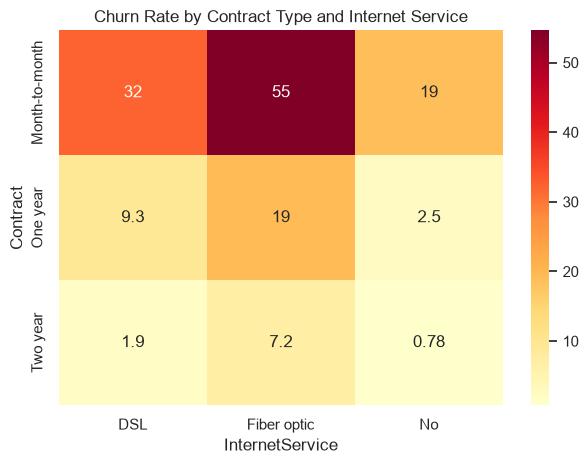

<Figure size 640x480 with 0 Axes>

In [13]:
q11 = """
    SELECT
        b.Contract,
        s.InternetService,
        ROUND(
            SUM(CASE WHEN b.Churn='Yes' THEN 1 ELSE 0 END)*100.0
            /COUNT(*),
            2
        ) AS ChurnRate
    FROM services s
    JOIN customers c
    ON s.customerID=c.customerID
    JOIN billing b
    ON c.customerID=b.customerID
    GROUP BY
        b.Contract,
        s.InternetService
"""

df11 = pd.read_sql(q11, engine)

heatmap_data = df11.pivot_table(
    index="Contract",
    columns="InternetService",
    values="ChurnRate"
)

sns.set_theme(style="white")

sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd')
plt.title('Churn Rate by Contract Type and Internet Service')

plt.tight_layout()
plt.show()    

plt.savefig('Churn_Rate by Contract_Type and Internet_Service.png')

## Insight
###### Month-to-month + Fiber optic combination ka churn RATE sabse zyada hai (55%) — ye highest-risk customer segment hai
###### Two year contract wale customers me churn rate har internet service type ke liye 8% se kam hai, jo strong retention dikhata hai
###### Ye heatmap raw count-based bar charts (Contract count, InternetService count) se zyada meaningful hai kyunki ye base size normalize karke fair RATE comparison deta hai — Contract aur InternetService dono milkar sabse strong combined churn predictor lag rahe hain